# 4-1 ピーク検出(個別,+検出シミュレーション)
# Done
## Fig 2. bin数分布 ###
## Fig 4. NF検出数の確率分布
```
\includegraphics[width=\columnwidth]{figures/Number_of_3posdev_in_11bins1000obs_1000trials}
% simulated in SEDquest2.ipynb
% mean :  30.557
% std  :  5.593813636509532
\includegraphics[width=\columnwidth]{figures/3c454.3_simulated_npeaks.png}
% simulated from draw_detectedPeaks_distribution(),
% in SEDquest4-1.ipynb
% mean :  45.161
% std  :  6.285783881108227
\caption{(a) Distribution of $K$ for $n=11$. (b) Distribution of $K'$ using the $n_i$ and $w_i$ from Fig.~\ref{fig:3c454.3_nbins}.}
\label{fig:example_probability_distribution}
\end{figure}
```

# ★★★ Codes
##  - Peak detection method: 
The method is used in the data analysis, as well as in the numerical 

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit

nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1
###################
# Peak detection
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  # significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths#,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths#,significances
  

## - Utility functions

### Gaussian
### Red.Chisq. calculation
### plotSED

In [45]:

def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

def plotSED(x, y, yerr, fitted_line, peakinitbins, peaklengths, residuals,reduced_chi_squared, obsdate, idx):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
      plt.plot(x[peakbininit:peakbininit+peaklength],
               y[peakbininit:peakbininit+peaklength], label='Peak Region', marker='x', linestyle='-')
  plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  plt.show()


## - Estimation of the number of detected peaks 
### theoretical: via Markov Chain

14 bins from 9 to 22


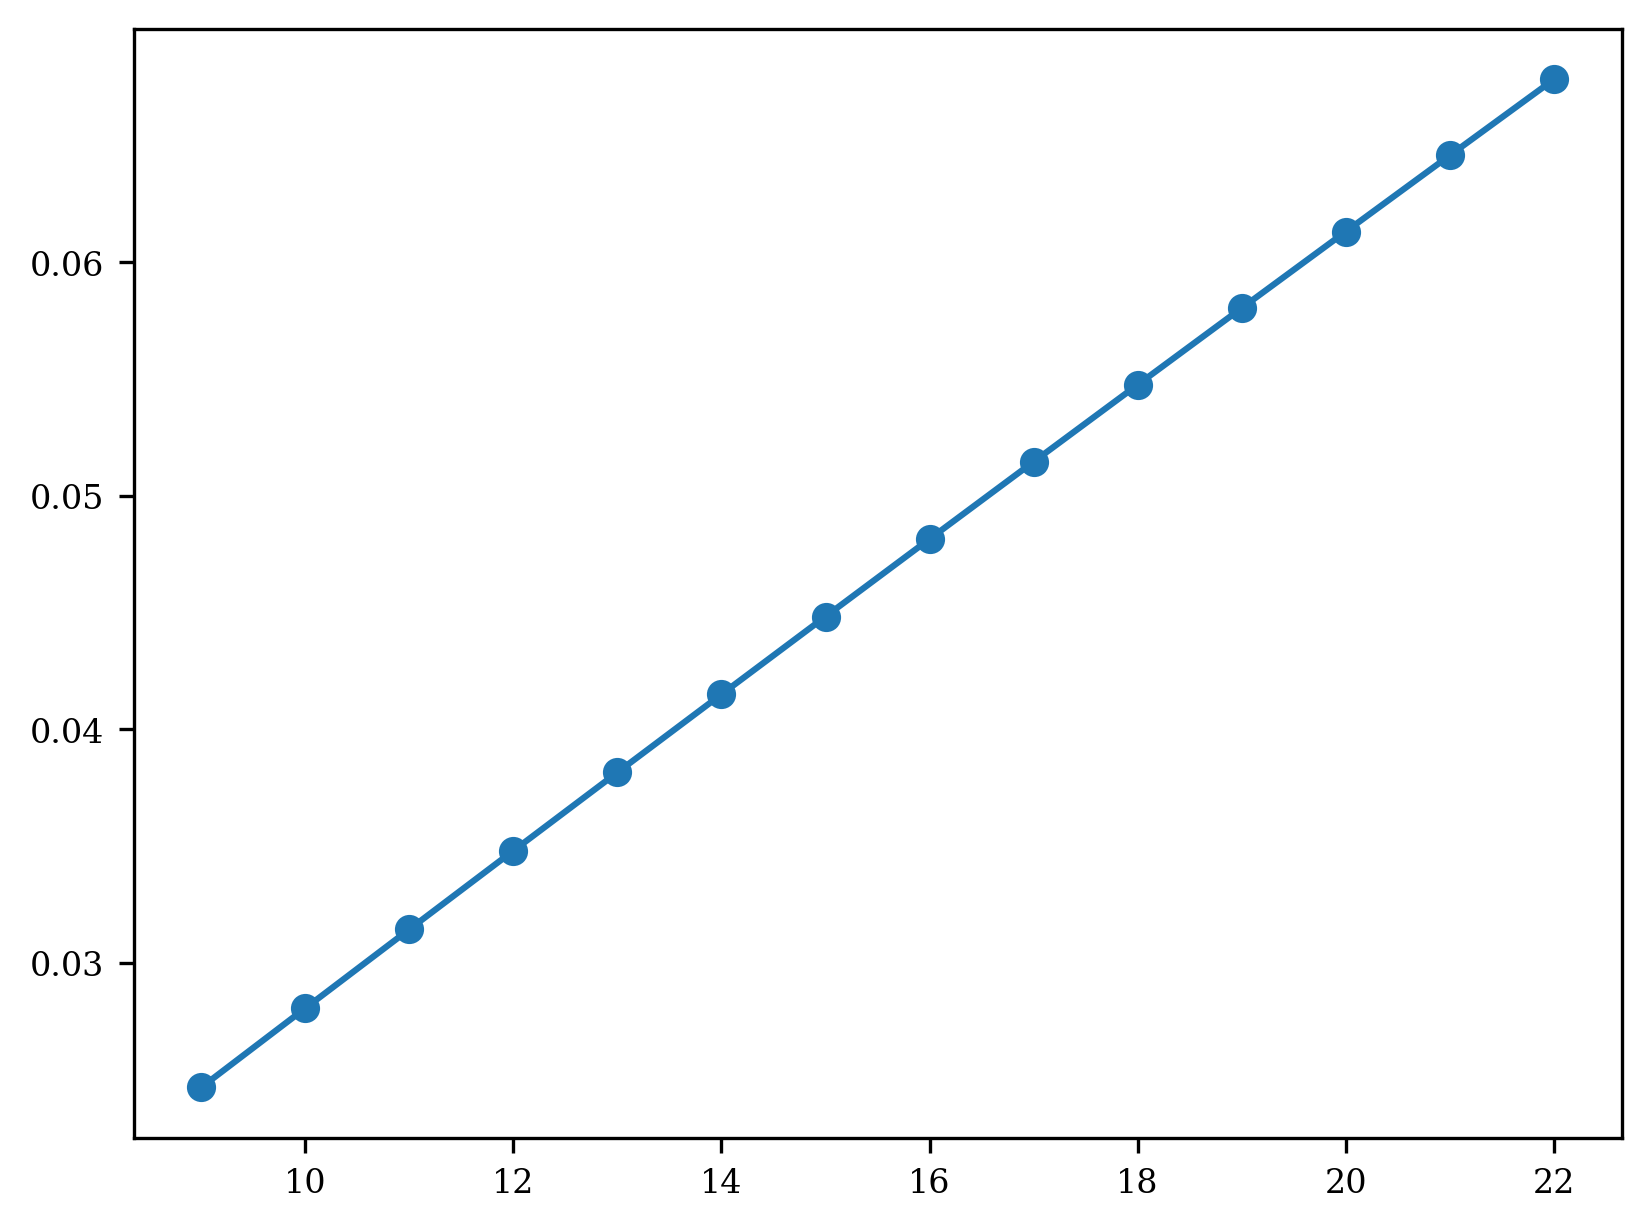

In [46]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### numerical: via simulated residual plots

Detected peaks Distribution by simulation
 - Simulating SEDs (Residuals) based on the numbers of obs with the given data points,
 - which could be multiplied to around 1000 observations
 - Detect the peaks
 - Repeat 1000 times
 - Obtain the distribution of the number of detected peaks

In [47]:

import numpy as np

def draw_detectedPeaks_distribution(array_nbins, array_nobs, normalization=True, ntrials=1000):
  # nconsecutive = 3

  sample_normalization_factor = 1.0
  if normalization:
    sample_normalization_factor = int(1000./np.sum(array_nobs))+1
    print(1000.0/np.sum(array_nobs))
    print('sample_normalization_factor', sample_normalization_factor)

  sample_size = int(np.sum(array_nbins*array_nobs*sample_normalization_factor)*ntrials)
  array_nobs = array_nobs * sample_normalization_factor
  print('sample_size', sample_size)
  print('bins = ', array_nbins)
  print('nobs = ', array_nobs)

  #############################################
  #  Simulate all the data points of all SEDs (assuming residual plots)
  #############################################
  mu, sigma = 0, 1.0
  s = np.random.normal(mu, sigma, sample_size)

  #############################################
  #  Peak detection and counting
  #############################################
  arr_n_detected_peaks = []
  for initpos_sample, i_trial in zip(range(0,sample_size,ntrials),range(ntrials)):    
    n_detected_peaks = 0
    pos_sample = initpos_sample
    for i_nbins,i_nobs in zip(array_nbins, array_nobs):        
      for i in range(pos_sample,int(pos_sample+i_nbins*i_nobs),int(i_nbins)):          
        # print(pos_sample, i_nbins, i_nobs, i)
        # print(s[i:i+int(i_nbins)])
        peakbininit = get_consecutive_bins(s[i:i+int(i_nbins)],nconsecutive)
        if peakbininit >= 0:
          # print('A peak detected at the bin #',peakbininit)
          # plt.plot(range(peakbininit, nbins),s[i+peakbininit:i+nbins], label='obs'+str(j), marker='o',linestyle='')
          # plt.plot(range(peakbininit, peakbininit+nconsecutive),s[i+peakbininit:i+peakbininit+3], label='obs'+str(j), marker='o',linestyle='-')
          n_detected_peaks += 1
          # plt.plot(range(nbins),s[i:i+nbins], label='obs'+str(j))
      pos_sample += int(i_nbins*i_nobs)
    arr_n_detected_peaks.append(n_detected_peaks)
    print('trial',i_trial, ': n_detected_peaks=', n_detected_peaks)
  # print('Detected peaks are ', arr_n_detected_peaks)
  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
  # draw a histogram of arr_n_detected_peaks
  import matplotlib.pyplot as plt
  # plt.hist(arr_n_detected_peaks, bins=20)
  # plt.xlabel('Number of observations with detected peaks')
  # plt.ylabel('Frequency')
  # plt.title('Histogram of probability of detecting a peak')
  # plt.show()  
  from scipy.optimize import curve_fit
  nbins = 20
  n, bins, patches = plt.hist(arr_n_detected_peaks, bins = nbins)
  plt.xlabel('Number of observations with detected peaks')
  plt.ylabel('# Trials')
  plt.title('Histogram of the number of detected peaks for '+str(ntrials)+' trials')
  # plt.show()
  print('-- Distribution of number of detected peaks --')
  print('mean : ',np.mean(arr_n_detected_peaks))
  print('std  : ',np.std(arr_n_detected_peaks))

  #############################################
  #  For publication
  #############################################
  fig, ax = plt.subplots(figsize=(1.6*3, 1*3), dpi=300)
  hist_nbins = ax.hist(arr_n_detected_peaks, bins=nbins, #np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), 
                      histtype='bar', color='steelblue', edgecolor='black', alpha=0.7)
  ax.set_xlabel('$K\prime$', fontsize=10)
  ax.set_ylabel('Counts', fontsize=10)
  ax.tick_params(axis='both', which='major', labelsize=8)
  ax.grid(axis='y', alpha=0.3, linestyle='--')
  # add '(a)' to the upper left corner
  ax.text(0.02, 0.95, '(b)', transform=ax.transAxes, fontsize=12, verticalalignment='top') 
  plt.tight_layout()
  plt.savefig("figures/Fig4b_distribution_of_Kprime_aanda.png", dpi=300, bbox_inches='tight')
  plt.savefig("figures/Fig4b_distribution_of_Kprime_aanda.pdf", dpi=300, bbox_inches='tight')
  print('nbins distribution:')
  print(  hist_nbins[0], hist_nbins[1][0:-1]+0.5, hist_nbins[2])
  plt.show()  

  #############################################
  #  Fit a Gaussian distribution to the data
  #############################################
#   xmin, xmax = plt.xlim()
#   x = np.linspace(xmin, xmax, nbins)
#   y = n
#   popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
#   # popt, pcov = curve_fit(gaussian, x, y)

#   plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
#   print('amplitude', popt[0])
#   print('mu', popt[1])
#   print('sigma', popt[2])
#   plt.yscale('log')
  plt.show()

## 主関数 eval_spectra (描画)

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit




def eval_spectra(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)

    ### fit the data  ###
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      residuals = (y-fitted_line(x))/yerr
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    
    residuals = (y-fitted_line(x))/yerr
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    peakinitbins, peaklengths = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])

    if len(peakinitbins) > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED(x, y , yerr, fitted_line,  peakinitbins, peaklengths, residuals, reduced_chi_squared, obsdate, idx)
      for peakbininit, peaklength in zip(peakinitbins, peaklengths):
        print(residuals[peakbininit:peakbininit+peaklength])
      # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
      # plt.plot(x,fitted_line(x),'-')
      # plt.plot(x[peakbininit:peakbininit+nconsecutive],
      #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')

      # plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
      # plt.xlabel('Energy [MeV]')
      # plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.show()

  ### bin数分布 ###
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  print('nbins distribution:')
  print(  hist_nbins[0], hist_nbins[1][0:-1]+0.5, hist_nbins[2])
  plt.show()
  
  ### detected peaks 分布 ###
  draw_detectedPeaks_distribution(hist_nbins[1][0:-1]+0.5,hist_nbins[0])
  plt.show()

  ### 各Eの residual 分布 ###
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  plt.show()

  
  ### residual 分布 ###
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

## PublicationVersion (2026.03.22)


In [49]:

def eval_spectra_forAandA(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)

    ### fit the data  ###
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      residuals = (y-fitted_line(x))/yerr
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    
    residuals = (y-fitted_line(x))/yerr
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    peakinitbins, peaklengths = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])

    if len(peakinitbins) > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED(x, y , yerr, fitted_line,  peakinitbins, peaklengths, residuals, reduced_chi_squared, obsdate, idx)
      for peakbininit, peaklength in zip(peakinitbins, peaklengths):
        print(residuals[peakbininit:peakbininit+peaklength])
      # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
      # plt.plot(x,fitted_line(x),'-')
      # plt.plot(x[peakbininit:peakbininit+nconsecutive],
      #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')

      # plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
      # plt.xlabel('Energy [MeV]')
      # plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.show()

  ### bin数分布 ###
  # fig, ax = plt.subplots(figsize=(8.8/2.54, 5), dpi=300)
  fig, ax = plt.subplots(figsize=(1.6*3, 1*3), dpi=300)
  hist_nbins = ax.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), 
                       histtype='bar', color='steelblue', edgecolor='black', alpha=0.7)
  ax.set_xlabel('Number of effective bins', fontsize=10)
  ax.set_ylabel('Counts', fontsize=10)
  ax.tick_params(axis='both', which='major', labelsize=8)
  ax.grid(axis='y', alpha=0.3, linestyle='--')
  plt.tight_layout()
  plt.savefig("figures/Fig2_nbins_distribution_aanda.png", dpi=300, bbox_inches='tight')
  plt.savefig("figures/Fig2_nbins_distribution_aanda.pdf", dpi=300, bbox_inches='tight')
  print('nbins distribution:')
  print(  hist_nbins[0], hist_nbins[1][0:-1]+0.5, hist_nbins[2])
  plt.show()  

  ### detected peaks 分布 ###
  draw_detectedPeaks_distribution(hist_nbins[1][0:-1]+0.5,hist_nbins[0])
  plt.show()

  ### 各Eの residual 分布 ###
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  plt.show()

  
  ### residual 分布 ###
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  # fig, ax = plt.subplots(figsize=(8.8/2.54, 5), dpi=300)
  fig, ax = plt.subplots(figsize=(1.6*3, 1*3), dpi=300)
  n, bins, patches =ax.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), 
                             histtype='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = ax.get_xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  ax.plot(x, gaussian(x, *popt), 'r-', linewidth=2, label='Gaussian fit')#, 'k', linewidth=2)
  ymin, ymax = ax.get_ylim()
  ax.set_ylim(0.8, ymax)
  ax.set_xlabel('Residuals (σ)', fontsize=10)
  ax.set_ylabel('Counts', fontsize=10)
  ax.set_yscale('log')
  ax.tick_params(axis='both', which='major', labelsize=8)
  ax.legend(fontsize=8)
  ax.grid(axis='y', alpha=0.3, linestyle='--')
  plt.tight_layout()
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

# ★★★ Execution on the data

/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_44436/637207384.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


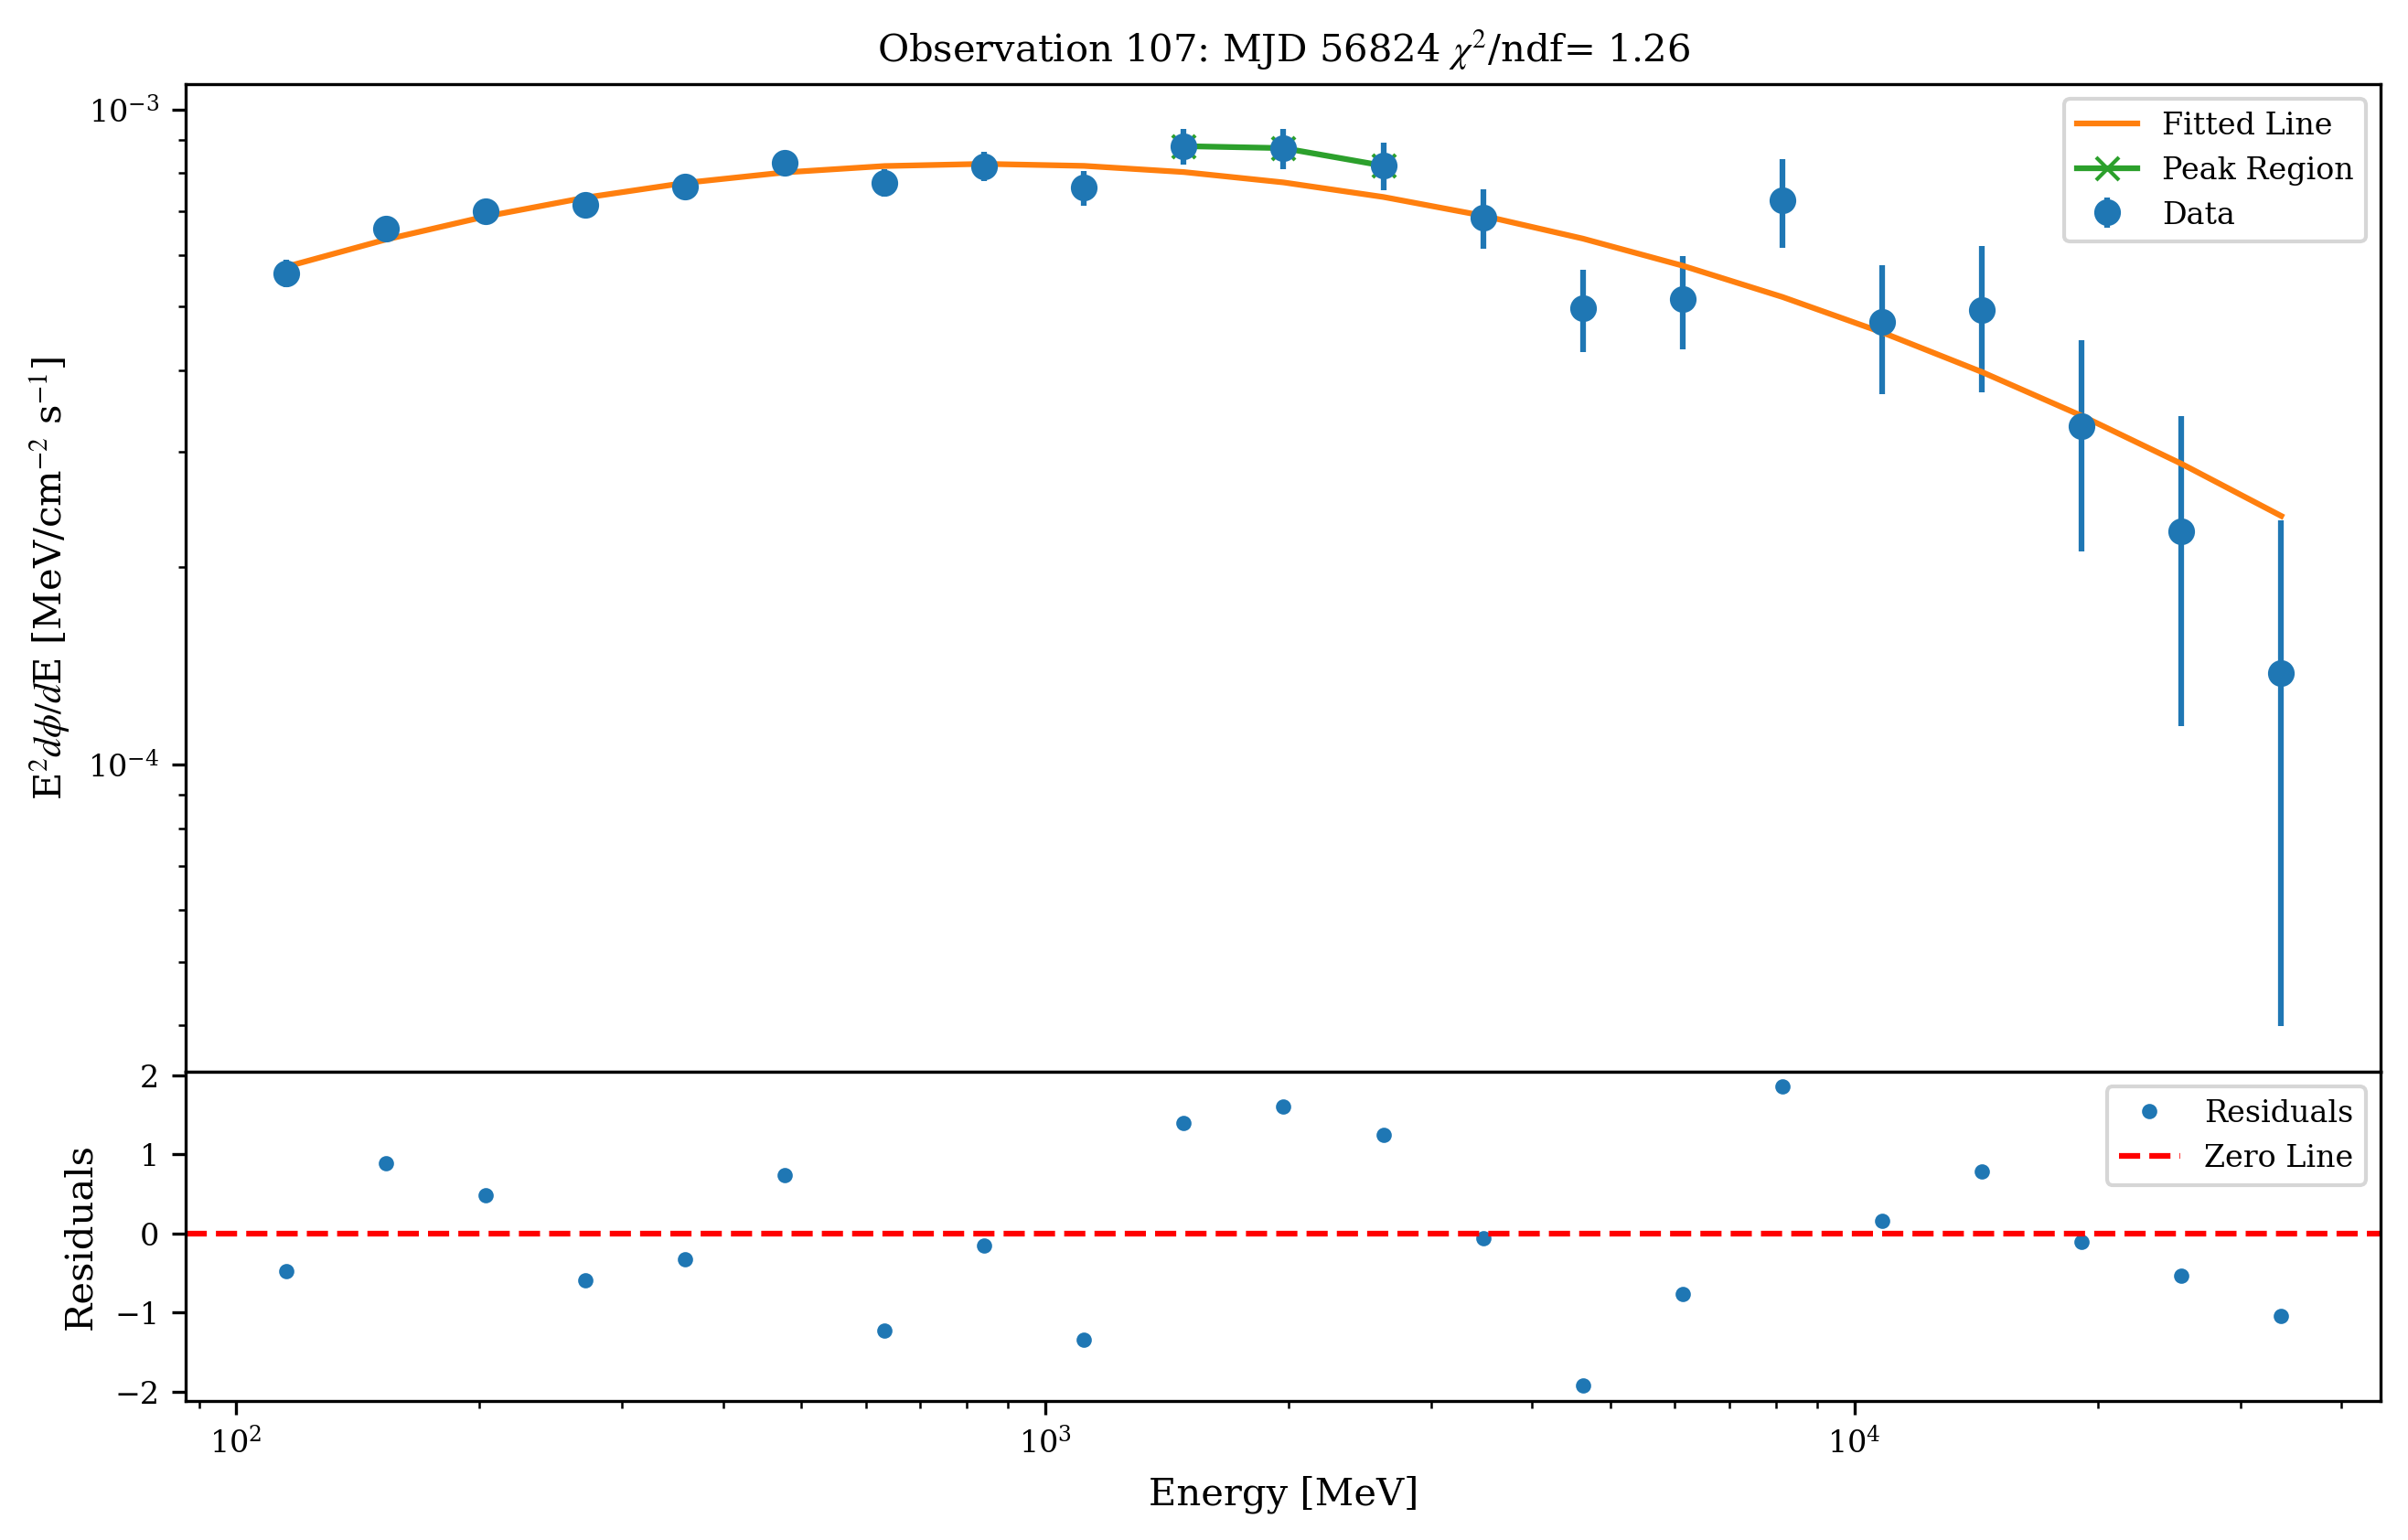

      e2dnde      
  MeV / (cm2 s)   
------------------
1.3984912943116743
1.5994265363664821
1.2420532374963023


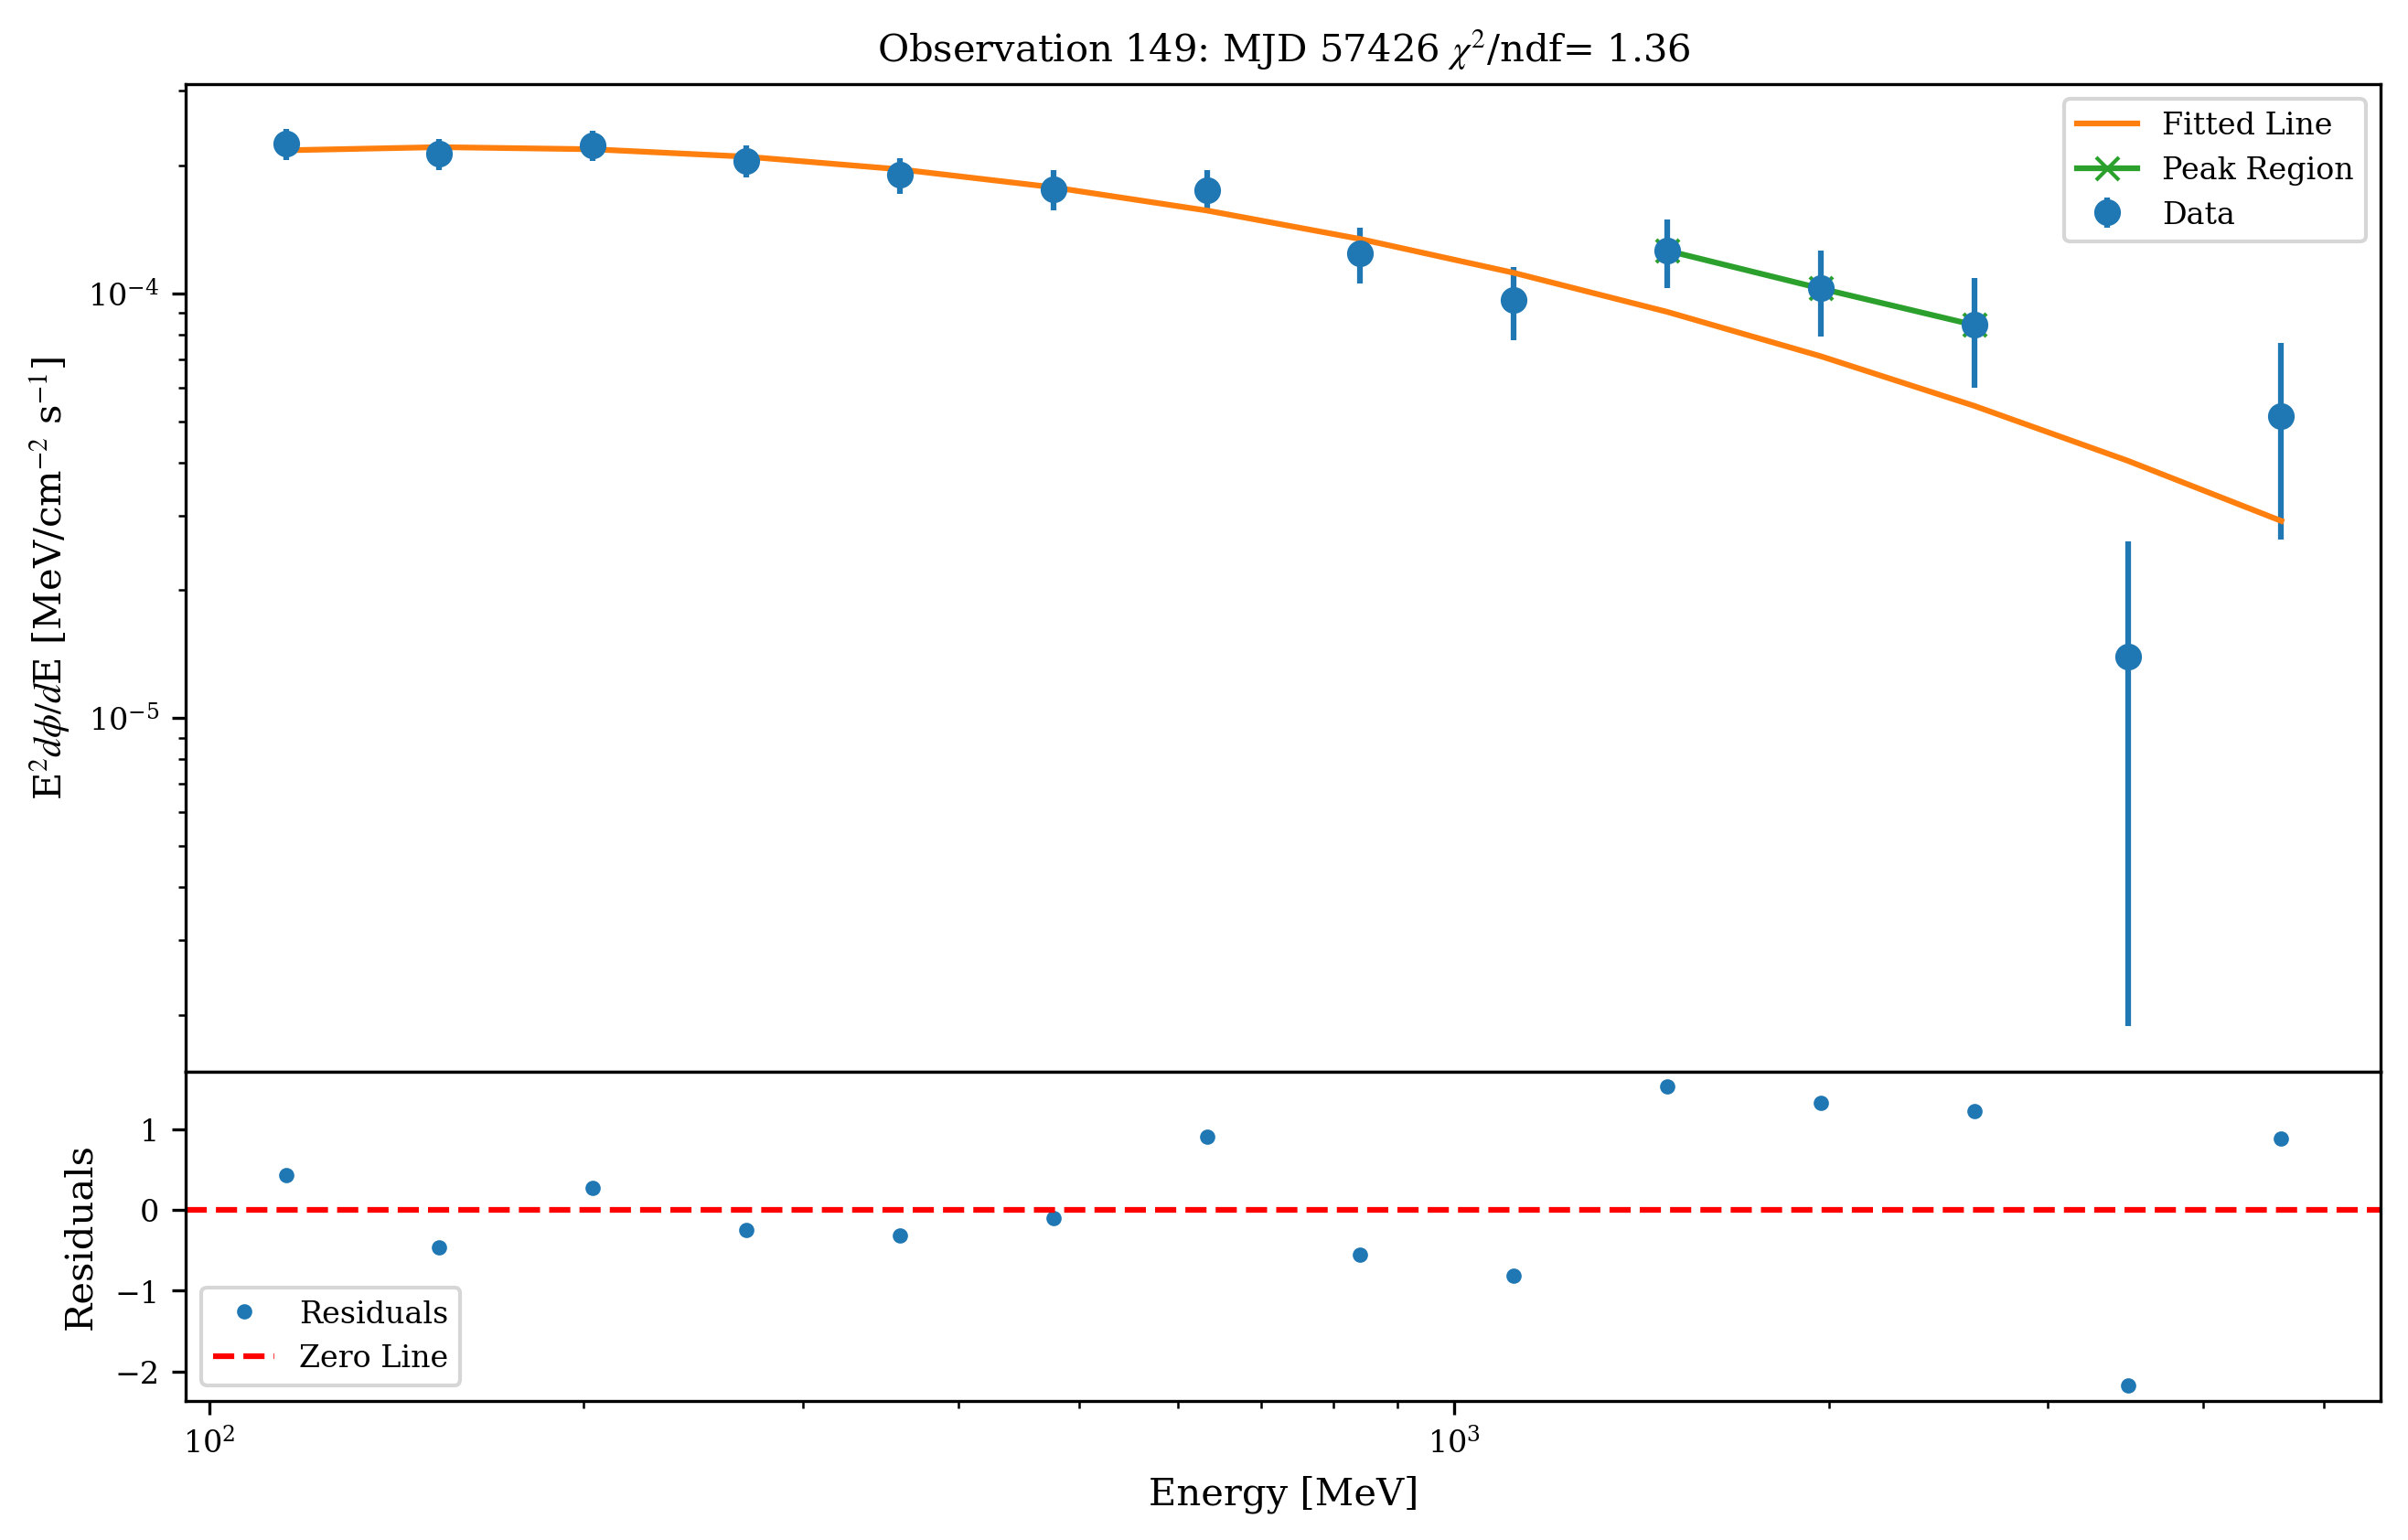

      e2dnde      
  MeV / (cm2 s)   
------------------
1.5355484056587083
1.3359096087400186
1.2257110003317486
nbins distribution:
[ 0.  9. 33. 47. 49. 42. 39. 28. 17.  8.  9.  2.  1.  0.] [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.] <BarContainer object of 14 artists>


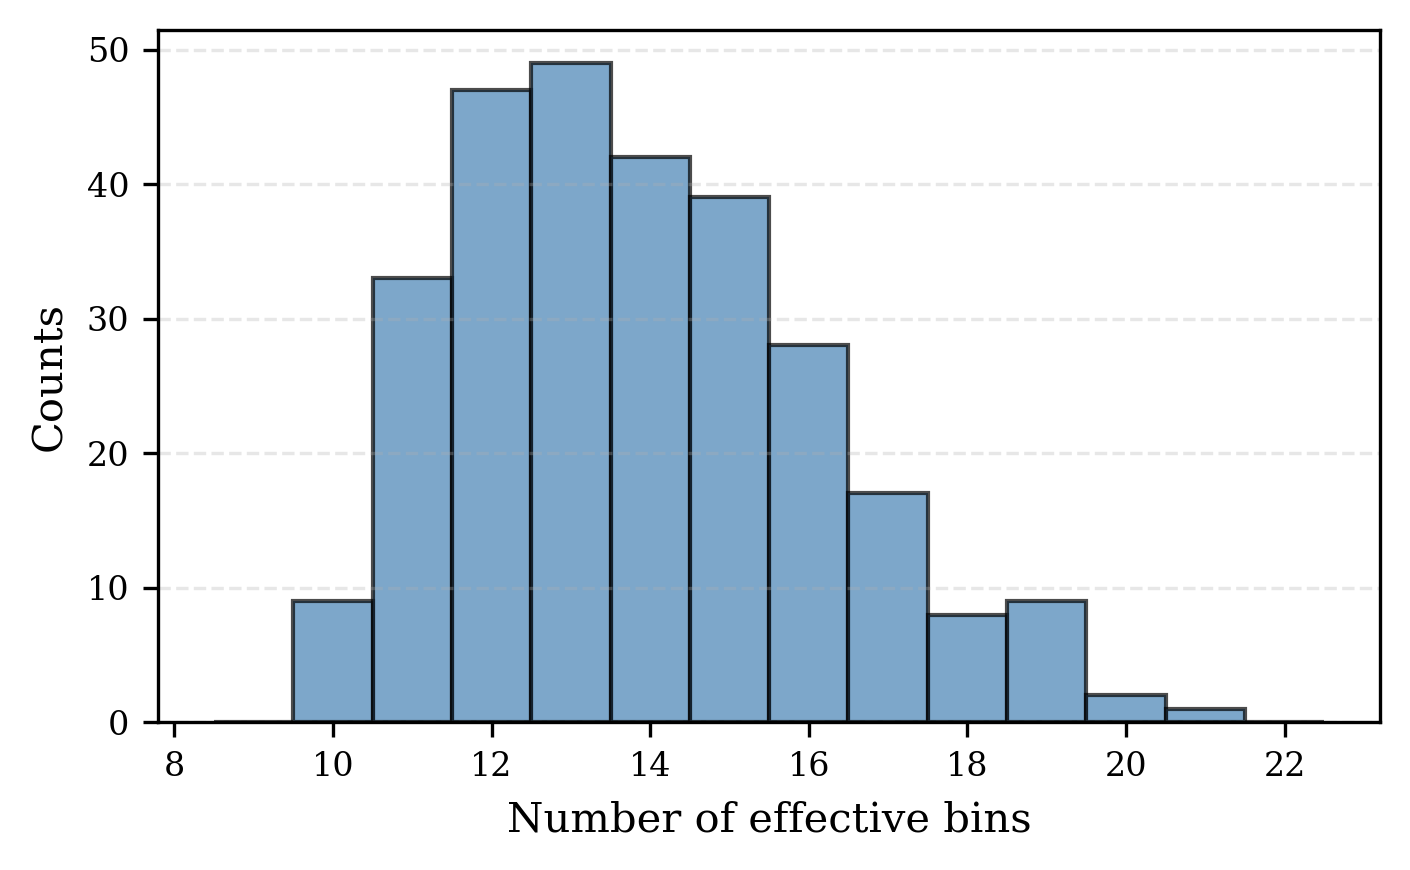

3.5211267605633805
sample_normalization_factor 4
sample_size 15760000
bins =  [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.]
nobs =  [  0.  36. 132. 188. 196. 168. 156. 112.  68.  32.  36.   8.   4.   0.]
trial 0 : n_detected_peaks= 50
trial 1 : n_detected_peaks= 46
trial 2 : n_detected_peaks= 43
trial 3 : n_detected_peaks= 41
trial 4 : n_detected_peaks= 42
trial 5 : n_detected_peaks= 43
trial 6 : n_detected_peaks= 41
trial 7 : n_detected_peaks= 37
trial 8 : n_detected_peaks= 41
trial 9 : n_detected_peaks= 41
trial 10 : n_detected_peaks= 40
trial 11 : n_detected_peaks= 43
trial 12 : n_detected_peaks= 42
trial 13 : n_detected_peaks= 35
trial 14 : n_detected_peaks= 48
trial 15 : n_detected_peaks= 45
trial 16 : n_detected_peaks= 43
trial 17 : n_detected_peaks= 46
trial 18 : n_detected_peaks= 42
trial 19 : n_detected_peaks= 45
trial 20 : n_detected_peaks= 48
trial 21 : n_detected_peaks= 51
trial 22 : n_detected_peaks= 41
trial 23 : n_detected_peaks= 48
trial 24 : n_detected_peak

In [ ]:

# eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
eval_spectra_forAandA('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264

# eval_spectra('data/3C454.3_allsed_7d_min11.ecsv')   # 3pos, 0neg/208
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')   # 8pos, 0neg/556
# eval_spectra('data/3C454.3_allsed_1d_2_min11.ecsv') # 7pos, 0neg/461, several peaks on 56830, sudden drop on 57562

# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 57562, 5) # show SEDs around MJD 57562


# eval_spectra('data/Mrk421_allsed_14d_min11.ecsv')   # 6pos, 1neg/394
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv')   # 5pos, 1neg/180, too low in lowestE on 57790
# show_SED('data/CTA102_allsed_14d_min11.ecsv', 57790, 20) # show SEDs around MJD 57790
# eval_spectra('data/3C279_allsed_14d_min11.ecsv')    # 6pos, 0neg/260
# eval_spectra('data/4C+21.35_allsed_14d_min11.ecsv') # 0pos, 0neg /101
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv')    # 5pos, 0neg/249　-> 3pos, 0neg/294
# eval_spectra('data/PKS1510-089_allsed_14d_min11.ecsv') # 2pos, 0neg/214
# eval_spectra('data/S20109+22_allsed_14d_min11.ecsv') # 0/50
# eval_spectra('data/S50716+71_allsed_14d_min11.ecsv')    # 4pos, 0neg/278
# eval_spectra('data/PKS1424-41_allsed_14d_min11.ecsv')    # 3pos, 0neg/297

Creating A&A format publication figures...


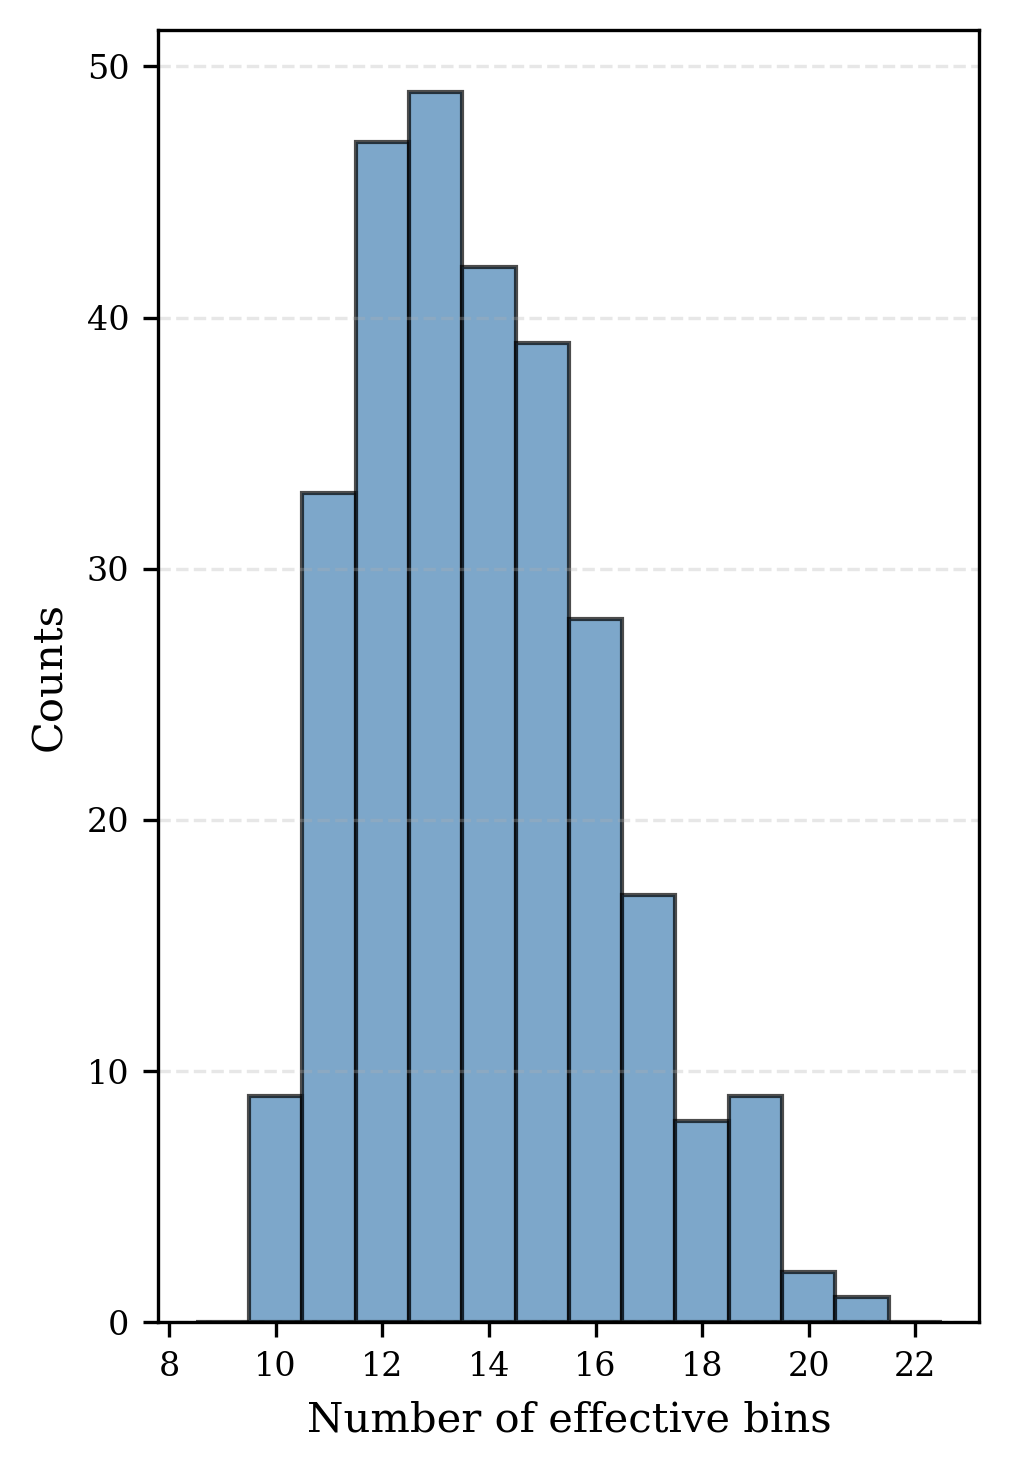

Fig 2 saved: nbins distribution


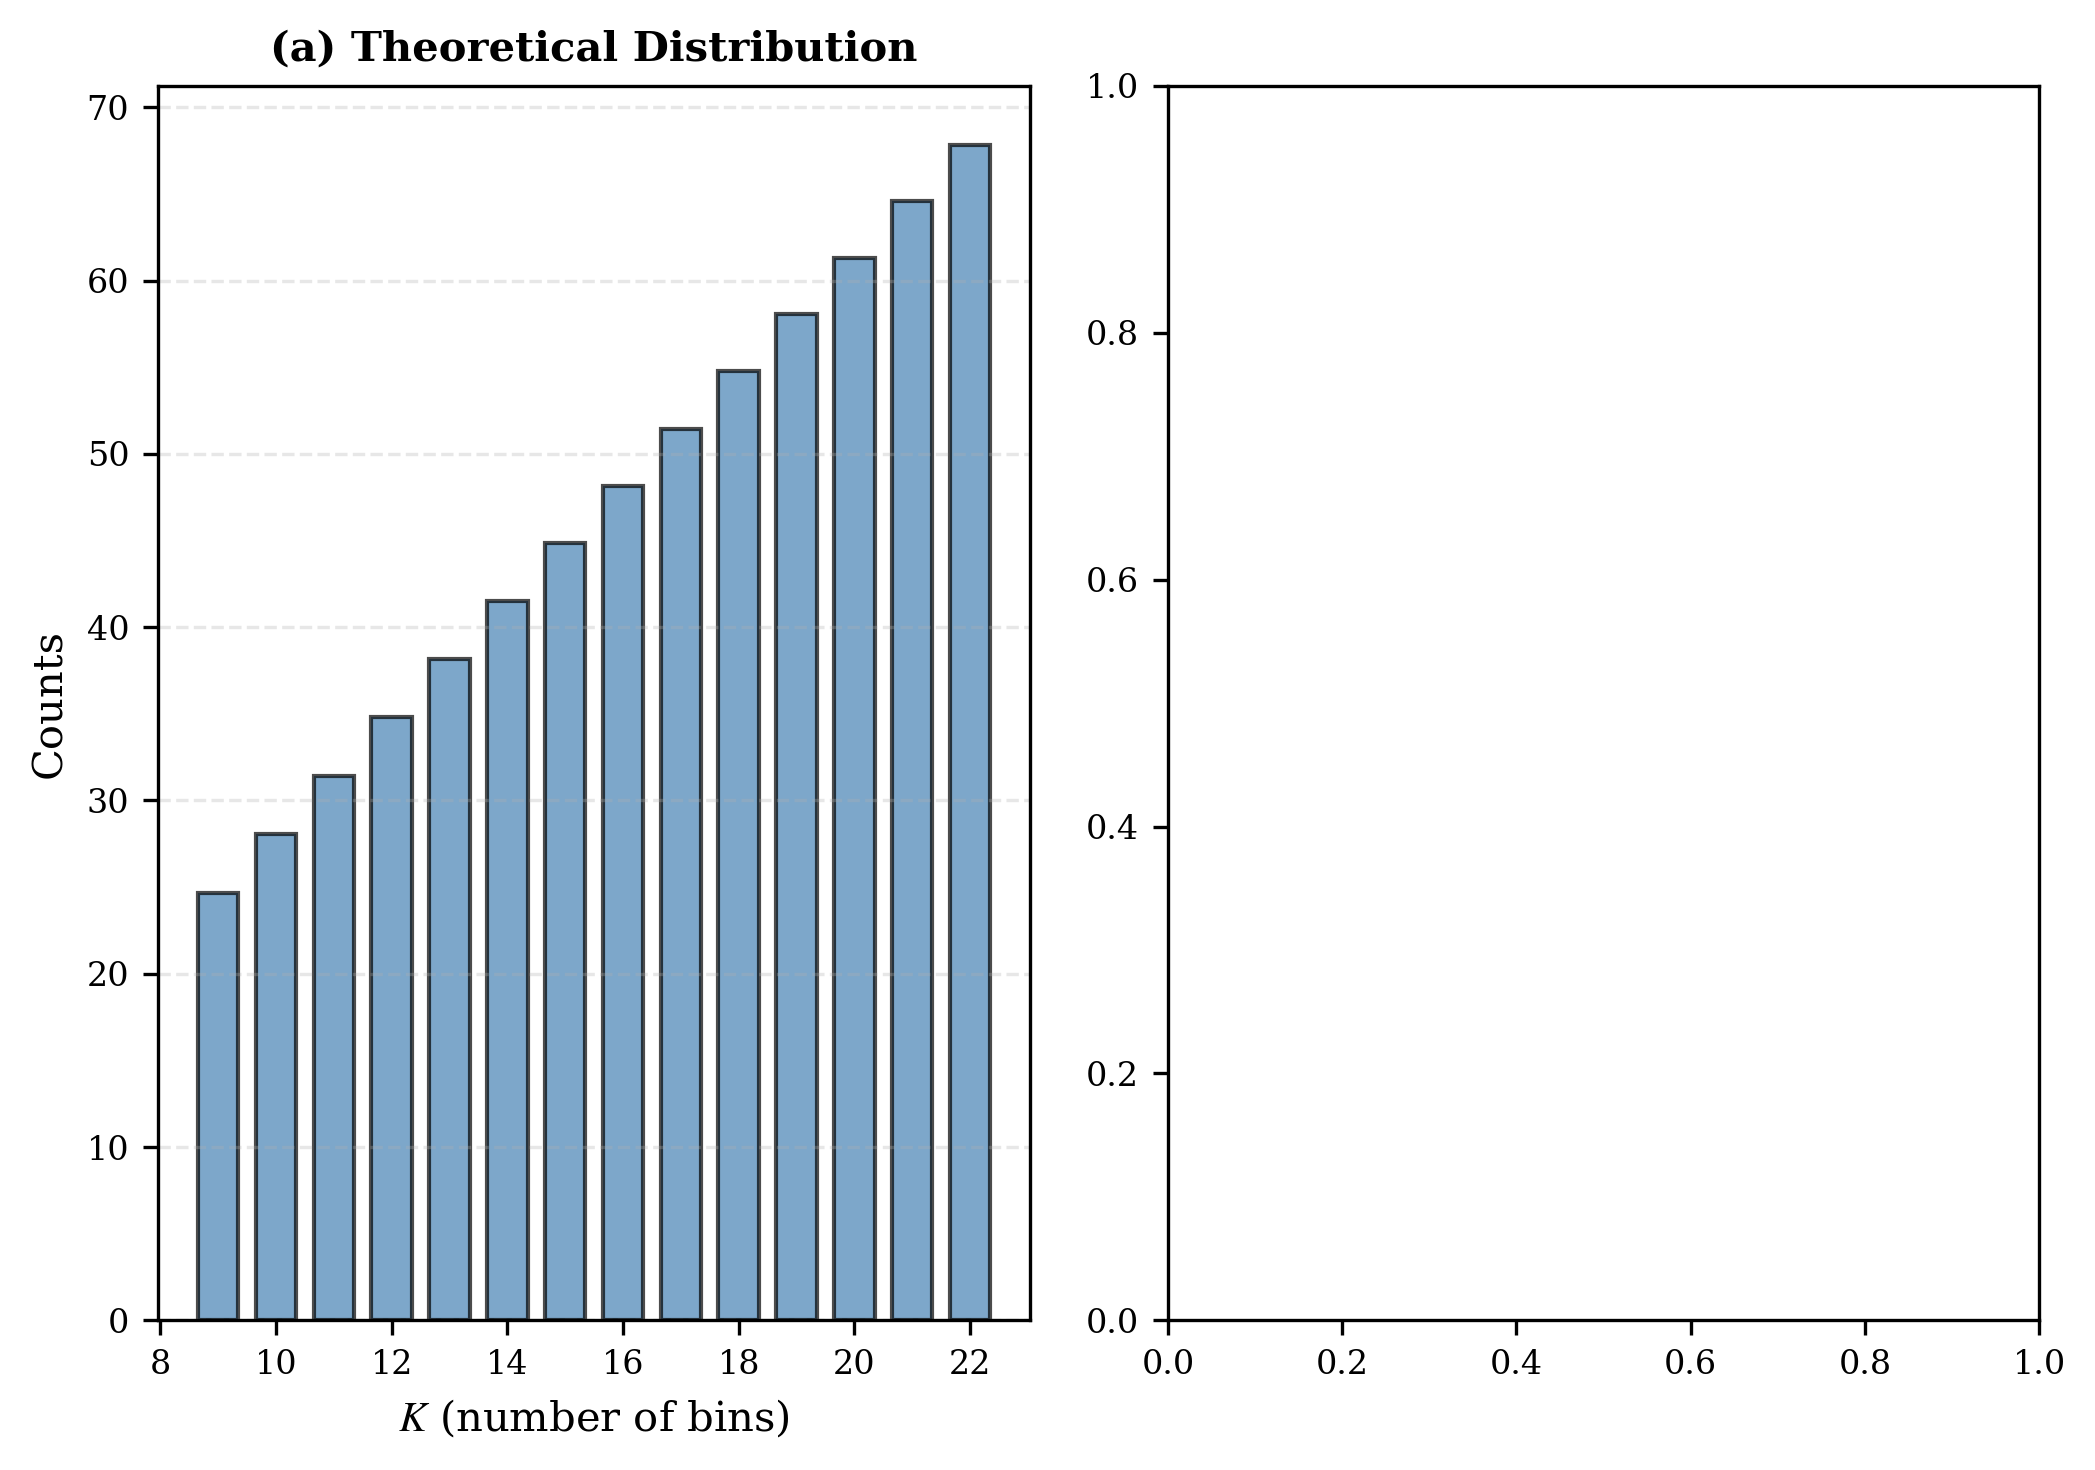

Fig 4 saved: Distribution of detected peaks


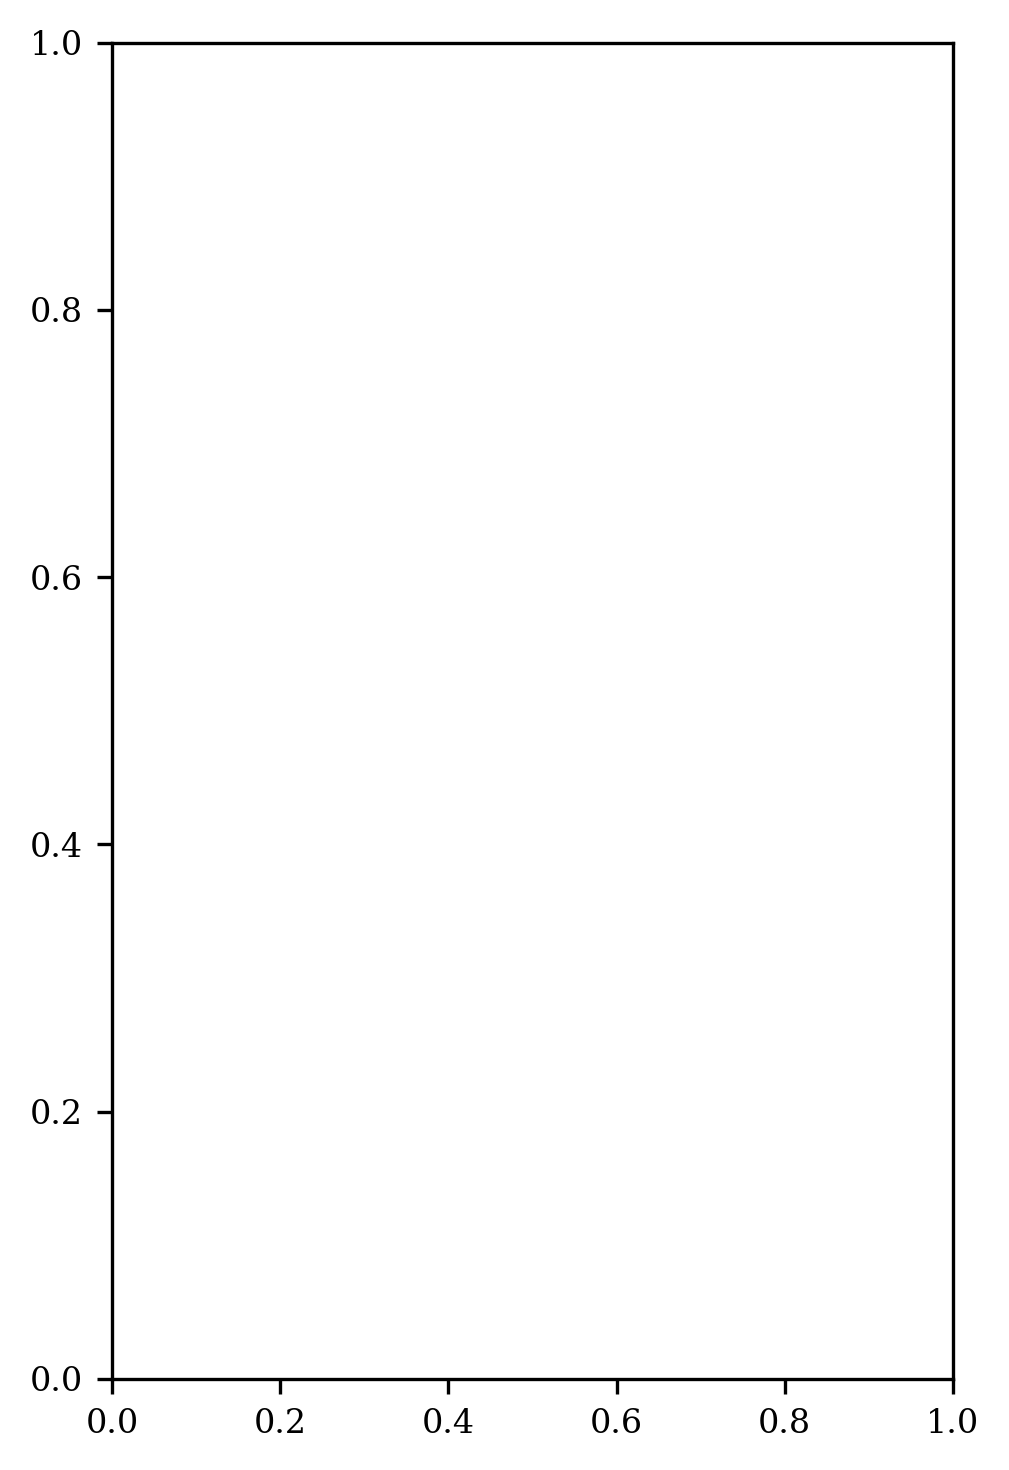

Residuals distribution saved


In [ ]:
# ===== Publication-Quality Histograms for A&A Format =====

import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for A&A publication style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'mathtext.fontset': 'stix',
})

def create_aanda_histogram_fig2():
    """Create Fig 2: nbins distribution in A&A format"""
    # A&A single column: 8.8 cm = 3.46 inches
    fig, ax = plt.subplots(figsize=(8.8/2.54, 5), dpi=300)
    
    # Use the nbins histogram data from the eval_spectra run
    # Recreate by running eval_spectra if needed, or use sample data
    hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), 
                          histtype='bar', color='steelblue', edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Number of effective bins', fontsize=10)
    ax.set_ylabel('Counts', fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig("figures/Fig2_nbins_distribution_aanda.png", dpi=300, bbox_inches='tight')
    plt.savefig("figures/Fig2_nbins_distribution_aanda.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig 2 saved: nbins distribution")

def create_aanda_histogram_fig4():
    """Create Fig 4: Distribution of detected peaks (K and K') in A&A format with subpanels"""
    # For two subpanels side by side: ~7 inches total width
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18/2.54, 5), dpi=300)
    
    # Panel (a): From Markov Chain (theoretical K)
    nbinsmin_theory = 9
    nbinsmax_theory = 22
    p_theory = (1 - 0.68) / 2.0
    P_theory = np.array([[1-p_theory, p_theory, 0, 0],
                         [1-p_theory, 0, p_theory, 0],
                         [1-p_theory, 0, 0, p_theory],
                         [0, 0, 0, 1]])
    A_theory = np.matrix(P_theory)
    probs_theory = []
    for ibins in range(nbinsmin_theory, nbinsmax_theory+1):
        B_theory = A_theory**ibins
        probs_theory.append(B_theory[0, 3])
    
    # Create histogram for theoretical K
    K_values = np.arange(nbinsmin_theory, nbinsmax_theory+1)
    ax1.bar(K_values, np.array(probs_theory)*1000, width=0.7, color='steelblue', 
            edgecolor='black', alpha=0.7)
    ax1.set_xlabel(r"$K$ (number of bins)", fontsize=10)
    ax1.set_ylabel("Counts", fontsize=10)
    ax1.set_title("(a) Theoretical Distribution", fontsize=10, fontweight='bold')
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Panel (b): From simulation (K' with varying n_i, w_i)
    # This uses arr_n_detected_peaks from draw_detectedPeaks_distribution
    if 'arr_n_detected_peaks' in dir():
        n_sim, bins_sim, patches_sim = ax2.hist(arr_n_detected_peaks, bins=15, 
                                                 histtype='bar', color='coral', 
                                                 edgecolor='black', alpha=0.7)
        ax2.set_xlabel(r"$K'$ (detected peaks)", fontsize=10)
        ax2.set_ylabel("Counts", fontsize=10)
        ax2.set_title("(b) Simulated Distribution", fontsize=10, fontweight='bold')
        ax2.tick_params(axis='both', which='major', labelsize=8)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add statistics as text
        mean_detected = np.mean(arr_n_detected_peaks)
        std_detected = np.std(arr_n_detected_peaks)
        ax2.text(0.98, 0.97, f'μ = {mean_detected:.1f}\nσ = {std_detected:.2f}', 
                transform=ax2.transAxes, fontsize=8, verticalalignment='top',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig("figures/Fig4_detected_peaks_distribution_aanda.png", dpi=300, bbox_inches='tight')
    plt.savefig("figures/Fig4_detected_peaks_distribution_aanda.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig 4 saved: Distribution of detected peaks")

def create_aanda_histogram_residuals():
    """Create residual distribution histogram in A&A format"""
    # A&A single column: 8.8 cm = 3.46 inches
    fig, ax = plt.subplots(figsize=(8.8/2.54, 5), dpi=300)
    
    if 't_residual' in dir() and len(t_residual) > 0:
        n_res, bins_res, patches_res = ax.hist(t_residual['residual'], 
                                               bins=np.arange(-5, 5.2, 0.2),
                                               histtype='bar', color='mediumseagreen', 
                                               edgecolor='black', alpha=0.7)
        
        # Fit Gaussian
        from scipy.optimize import curve_fit
        xmin_res, xmax_res = ax.get_xlim()
        x_fit = np.linspace(xmin_res, xmax_res, len(bins_res)-1)
        y_fit = n_res
        popt_res, _ = curve_fit(gaussian, x_fit, y_fit, p0=[1, np.mean(x_fit), np.std(x_fit)])
        ax.plot(x_fit, gaussian(x_fit, *popt_res), 'r-', linewidth=2, label='Gaussian fit')
        
        ax.set_xlabel('Residuals (σ)', fontsize=10)
        ax.set_ylabel('Counts', fontsize=10)
        ax.set_yscale('log')
        ax.set_ylim(0.8, max(n_res)*2)
        ax.legend(fontsize=8, loc='upper right')
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig("figures/Fig_residuals_distribution_aanda.png", dpi=300, bbox_inches='tight')
    plt.savefig("figures/Fig_residuals_distribution_aanda.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    print("Residuals distribution saved")

# Execute the functions
print("=" * 60)
print("Creating A&A format publication figures...")
print("=" * 60)

try:
    create_aanda_histogram_fig2()
except Exception as e:
    print(f"Note: Fig 2 requires running eval_spectra first. Error: {e}")

try:
    create_aanda_histogram_fig4()
except Exception as e:
    print(f"Note: Fig 4 requires running draw_detectedPeaks_distribution first. Error: {e}")

try:
    create_aanda_histogram_residuals()
except Exception as e:
    print(f"Note: Residuals figure requires running eval_spectra first. Error: {e}")